In [3]:
import tensorflow as tf
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import SGD, Adam


In [4]:
print(tf.__version__)

2.21.0


In [5]:
try:
    loaded_data = np.loadtxt('./diabetes.csv', delimiter=',')
    x_data = loaded_data[:, 0:-1] #변수값들
    t_data = loaded_data[:,[-1]]  #정답
    print('x_data.shape =', x_data.shape)
    print('t_data.shape =', t_data.shape)
except Exception as err:
    print(str(err))

x_data.shape = (759, 8)
t_data.shape = (759, 1)


In [7]:
model = Sequential()

In [8]:
model.add(Dense(t_data.shape[1],input_shape=(x_data.shape[1],),activation='sigmoid'))

In [10]:
model.compile(optimizer=SGD(learning_rate=0.01),
              loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
hist = model.fit(x_data, t_data, epochs=500, validation_split=0.2, verbose=2)

Epoch 1/500
19/19 - 1s - 44ms/step - accuracy: 0.3542 - loss: 0.7988 - val_accuracy: 0.3684 - val_loss: 0.7857
Epoch 2/500
19/19 - 0s - 8ms/step - accuracy: 0.3690 - loss: 0.7595 - val_accuracy: 0.3816 - val_loss: 0.7502
Epoch 3/500
19/19 - 0s - 7ms/step - accuracy: 0.4086 - loss: 0.7271 - val_accuracy: 0.4276 - val_loss: 0.7209
Epoch 4/500
19/19 - 0s - 11ms/step - accuracy: 0.4646 - loss: 0.7002 - val_accuracy: 0.4539 - val_loss: 0.6968
Epoch 5/500
19/19 - 0s - 9ms/step - accuracy: 0.5502 - loss: 0.6781 - val_accuracy: 0.5592 - val_loss: 0.6770
Epoch 6/500
19/19 - 0s - 16ms/step - accuracy: 0.6573 - loss: 0.6599 - val_accuracy: 0.6053 - val_loss: 0.6608
Epoch 7/500
19/19 - 0s - 8ms/step - accuracy: 0.6936 - loss: 0.6450 - val_accuracy: 0.6645 - val_loss: 0.6475
Epoch 8/500
19/19 - 0s - 7ms/step - accuracy: 0.7397 - loss: 0.6327 - val_accuracy: 0.7237 - val_loss: 0.6366
Epoch 9/500
19/19 - 0s - 7ms/step - accuracy: 0.7529 - loss: 0.6226 - val_accuracy: 0.7434 - val_loss: 0.6276
Epoch 1

In [12]:
model.evaluate(x_data, t_data)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7708 - loss: 0.4793 


[0.4792693257331848, 0.7707509994506836]

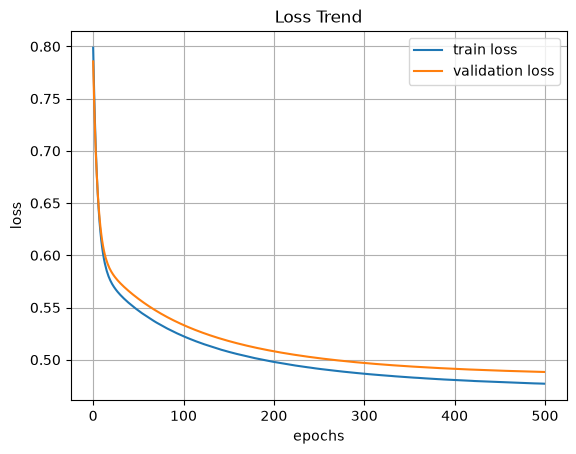

In [13]:
import matplotlib.pyplot as plt

plt.title('Loss Trend')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.grid()
plt.plot(hist.history['loss'], label='train loss')
plt.plot(hist.history['val_loss'], label='validation loss')
plt.legend(loc='best')
plt.show()

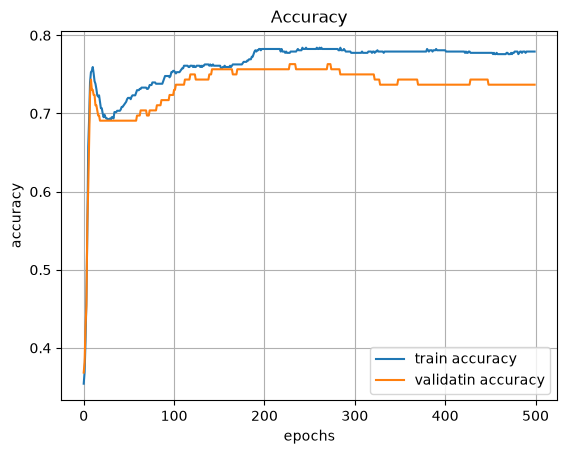

In [15]:
import matplotlib.pyplot as plt

plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.grid()
plt.plot(hist.history['accuracy'], label='train accuracy')
plt.plot(hist.history['val_accuracy'], label='validatin accuracy')
plt.legend(loc='best')
plt.show()